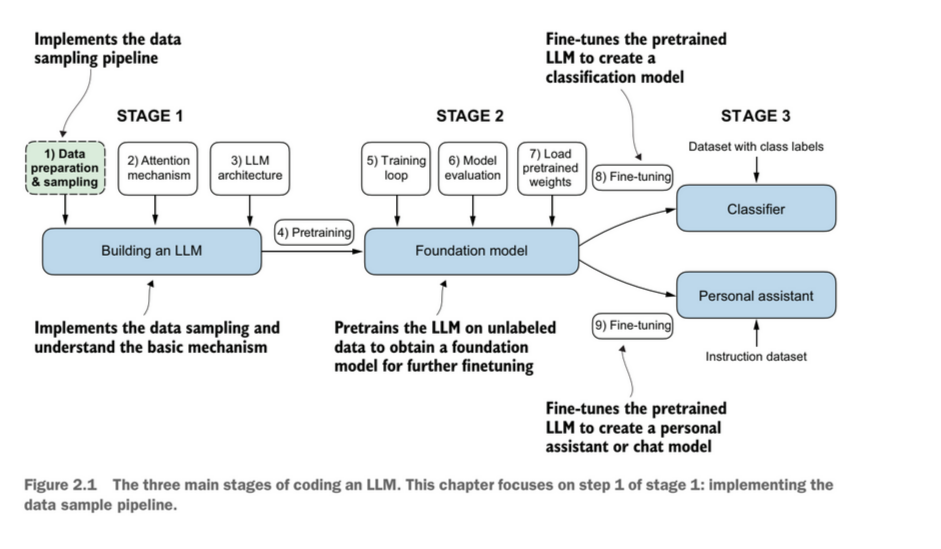

# Data: The Verdict


In [ ]:
import urllib.request 
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)


('the-verdict.txt', <http.client.HTTPMessage at 0x7f66af6d5670>)

In [ ]:
# open 
with open(file_path, "r", encoding="utf-8") as f: 
    raw_text = f.read()

print(f"Total number of characters: {len(raw_text)}")
print(raw_text[:99])

Total number of characters: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [ ]:
# basic split words 

import re 
text = "hello, world. This, is a test!"
result = re.split(r'([,.:;?!_"()]|--|\s)', text)
# remove whitespace
result = [item.strip() for item in result if item.strip()]
print(result)

['hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '!']


In [ ]:

preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])



['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [ ]:
# convert them into vocab 
all_words = sorted(set(preprocessed))
print(f"len: {len(all_words)}")


len: 1130


In [ ]:
vocab = {token: id for id, token in enumerate(all_words)}

# print first 50 item 
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50: break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


# Tokenizer Class

In [ ]:
# the vocab is only a dictionary which map word or subword into 
class SimpleTokenizerV1: # -> receive vocab and encode, decode base on the input vocab
    def __init__(self, vocab): 
        self.str_to_int = vocab 
        self.int_to_str = {id: token for token, id in vocab.items()}
    
    # encode text into id, look up to vocab dict
    def encode(self, text): 
        # preprocessing text 
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text) # list 
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ] 
        print(preprocessed)
        # return list of ids 
        ids = [self.str_to_int.get(token) for token in preprocessed]

        return ids
        
    def decode(self, ids): 
        text = " ".join([self.int_to_str[id] for id in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        
        return text 


tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know,"
Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

['"', 'It', "'", 's', 'the', 'last', 'he', 'painted', ',', 'you', 'know', ',', '"', 'Mrs', '.', 'Gisburn', 'said', 'with', 'pardonable', 'pride', '.']
[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [ ]:
# add special token 
all_words  = []
all_words.extend(["<|UNK|>", "<|ENDOFTEXT|>"])
all_words.extend(sorted(list(set(preprocessed))))
vocab = {token: id for id, token in enumerate(all_words)}

print(vocab)


{'<|UNK|>': 0, '<|ENDOFTEXT|>': 1, '!': 2, '"': 3, "'": 4, '(': 5, ')': 6, ',': 7, '--': 8, '.': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'Ah': 14, 'Among': 15, 'And': 16, 'Are': 17, 'Arrt': 18, 'As': 19, 'At': 20, 'Be': 21, 'Begin': 22, 'Burlington': 23, 'But': 24, 'By': 25, 'Carlo': 26, 'Chicago': 27, 'Claude': 28, 'Come': 29, 'Croft': 30, 'Destroyed': 31, 'Devonshire': 32, 'Don': 33, 'Dubarry': 34, 'Emperors': 35, 'Florence': 36, 'For': 37, 'Gallery': 38, 'Gideon': 39, 'Gisburn': 40, 'Gisburns': 41, 'Grafton': 42, 'Greek': 43, 'Grindle': 44, 'Grindles': 45, 'HAD': 46, 'Had': 47, 'Hang': 48, 'Has': 49, 'He': 50, 'Her': 51, 'Hermia': 52, 'His': 53, 'How': 54, 'I': 55, 'If': 56, 'In': 57, 'It': 58, 'Jack': 59, 'Jove': 60, 'Just': 61, 'Lord': 62, 'Made': 63, 'Miss': 64, 'Money': 65, 'Monte': 66, 'Moon-dancers': 67, 'Mr': 68, 'Mrs': 69, 'My': 70, 'Never': 71, 'No': 72, 'Now': 73, 'Nutley': 74, 'Of': 75, 'Oh': 76, 'On': 77, 'Once': 78, 'Only': 79, 'Or': 80, 'Perhaps': 81, 'Poor': 82, 'Profe

In [ ]:
# the vocab is only a dictionary which map word or subword into 
class SimpleTokenizerV2: # -> receive vocab and encode, decode base on the input vocab
    def __init__(self, vocab): 
        self.str_to_int = vocab 
        self.int_to_str = {id: token for token, id in vocab.items()}
    
    # encode text into id, look up to vocab dict
    def encode(self, text): 
        # preprocessing text 
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text) # list 
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ] 
        
        # add unknown word
        preprocessed = [
            item if item in self.str_to_int else "<|UNK|>" for item in preprocessed
        ]
        
        print(preprocessed)
        # return list of ids 
        ids = [self.str_to_int.get(token) for token in preprocessed]

        return ids
        
    def decode(self, ids): 
        text = " ".join([self.int_to_str[id] for id in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        
        return text 

In [ ]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|ENDOFTEXT|> ".join((text1, text2))
print(text)

tokenizer = SimpleTokenizerV2(vocab)
ids = tokenizer.encode(text)
print(ids)
text_decoded = tokenizer.decode(ids)
print(text_decoded)

Hello, do you like tea? <|ENDOFTEXT|> In the sunlit terraces of the palace.
['<|UNK|>', ',', 'do', 'you', 'like', 'tea', '?', '<|ENDOFTEXT|>', 'In', 'the', 'sunlit', 'terraces', 'of', 'the', '<|UNK|>', '.']
[0, 7, 357, 1128, 630, 977, 12, 1, 57, 990, 958, 986, 724, 990, 0, 9]
<|UNK|>, do you like tea? <|ENDOFTEXT|> In the sunlit terraces of the <|UNK|>.


# BytePairEncoding 


In [ ]:
# !pip install tiktoken
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")
text = (
"Hello, do you like tea? <|endoftext|> In the sunlit terraces"
"of someunknownPlace."
)

ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(ids)
text = tokenizer.decode(ids)
print(text)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]
Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


In [ ]:
# use tiktoken to encode The Verdict 
tokenizer = tiktoken.get_encoding("gpt2")
with open("the-verdict.txt", "r", encoding="utf-8") as f: 
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [ ]:
enc_sample = enc_text[50:]
context_size = 4 # the context size determines how many tokens are included in the input 
x = enc_sample[:context_size]
y = enc_sample[1: context_size+1]

for i in range(1, context_size+1): 
    context = enc_sample[:i]
    target = enc_sample[i]

    print(context, "--->", target)
    
# decode it 
for i in range(1, context_size+1): 
    context = enc_sample[:i]
    target = enc_sample[i]

    print(tokenizer.decode(context), "--->", tokenizer.decode([target]))
 



[290] ---> 4920
[290, 4920] ---> 2241
[290, 4920, 2241] ---> 287
[290, 4920, 2241, 287] ---> 257
 and --->  established
 and established --->  himself
 and established himself --->  in
 and established himself in --->  a


In [ ]:
# create a dataloader 
import torch 
from torch.utils.data import DataLoader, Dataset

class GPTDatasetv1(Dataset): 
    def __init__(self, text, tokenizer, max_length, stride): 
        self.text = text 
        self.tokenizer = tokenizer 
        self.max_length = max_length
        self.stride = stride # to create overlap between samples 
        
        self.input_ids = []
        self.target_ids = []
        self.token_ids = self.tokenizer.encode(self.text) 

        for i in range(0, len(self.token_ids) - self.max_length, self.stride): 
            input_chunks = self.token_ids[i: i + max_length] # each chunk have max_length token or each sample has max_length token
            target_chunks = self.token_ids[i+1: i + 1 + max_length] # shift 
            self.input_ids.append(torch.tensor(input_chunks))
            self.target_ids.append(torch.tensor(target_chunks))
        
         
    def __len__(self): 
        return len(self.input_ids) # shape (N (samples), max_length))
    
    def __getitem__(self, idx):
        # return a sample, which have a input tensor and a target tensor 
        return self.input_ids[idx], self.target_ids[idx] 
        

In [ ]:
# create instance 
def create_dataloaderv1(text, batch_size=4, max_length=256, 
                        stride=256, shuffle=True, drop_last=True,
                        num_workers=0): 
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetv1(text, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset=dataset, 
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader
    

In [ ]:
# test
dataloader = create_dataloaderv1(text=raw_text, batch_size=2, max_length=4, stride=4, shuffle=False)
data_iter = iter(dataloader)
batch = next(data_iter)
print(batch)



[tensor([[  40,  367, 2885, 1464],
        [1807, 3619,  402,  271]]), tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899]])]


# Embedding
- example, if you have 1000 tokens, so to represent it in vector, you create 1000 vectors, each vector has it own dim like 256 dim, 
- embedding is like one hot encoding but way more efficiency in computation
- embedding here is just like a look up table
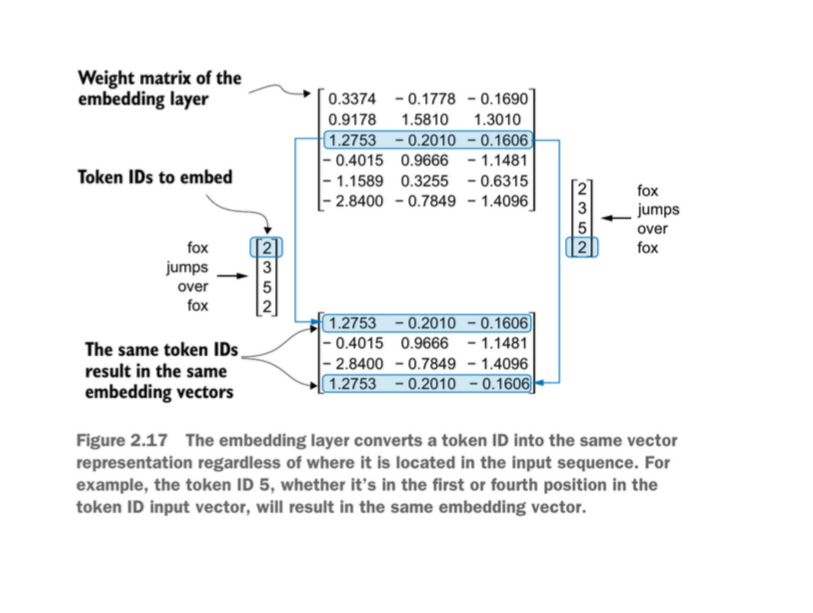

In [ ]:
vocab_size = 6 
embed_dim = 3 
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, embed_dim)
print(embedding_layer)
print(embedding_layer.weight)

print(embedding_layer(torch.tensor([3])))


# let apply to the real one 
print(tokenizer.n_vocab)
vocab_size = tokenizer.n_vocab
embed_dim = 256 
token_embedding_layer = torch.nn.Embedding(vocab_size, embed_dim)
print(token_embedding_layer)



Embedding(6, 3)
Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)
tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)
50257
Embedding(50257, 256)


## Embedding word positions

In [30]:
max_length = 4 

with open('the-verdict.txt', 'r', encoding='utf-8') as f: 
    text = f.read()

dataloader = create_dataloaderv1(text, batch_size=8, max_length=max_length,
                                 stride=max_length, shuffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("token IDs:\n", inputs)
print("\ninput shape:", inputs.shape)

# embed
token_embedding = token_embedding_layer(inputs)
print(token_embedding.shape)


token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

input shape: torch.Size([8, 4])
torch.Size([8, 4, 256])


In [32]:
# position embedding 
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, embed_dim) # each pos in seq len has it own vector embedded 
pos_embeddings = pos_embedding_layer(torch.arange(context_length))

print(pos_embeddings)
print(pos_embeddings.shape)


tensor([[ 0.2944,  1.6946, -0.1879,  ..., -0.0196,  0.8605,  0.0176],
        [-1.2162,  0.3617,  0.6800,  ...,  0.9172,  0.6879, -0.3622],
        [ 0.7821,  0.2635,  0.9459,  ...,  0.6895, -1.5726, -0.5220],
        [-2.5326,  0.0219,  0.2917,  ...,  0.2159,  1.7272, -0.8809]],
       grad_fn=<EmbeddingBackward0>)
torch.Size([4, 256])


In [34]:
input_embeddings = token_embedding + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


# Full Pipeline 
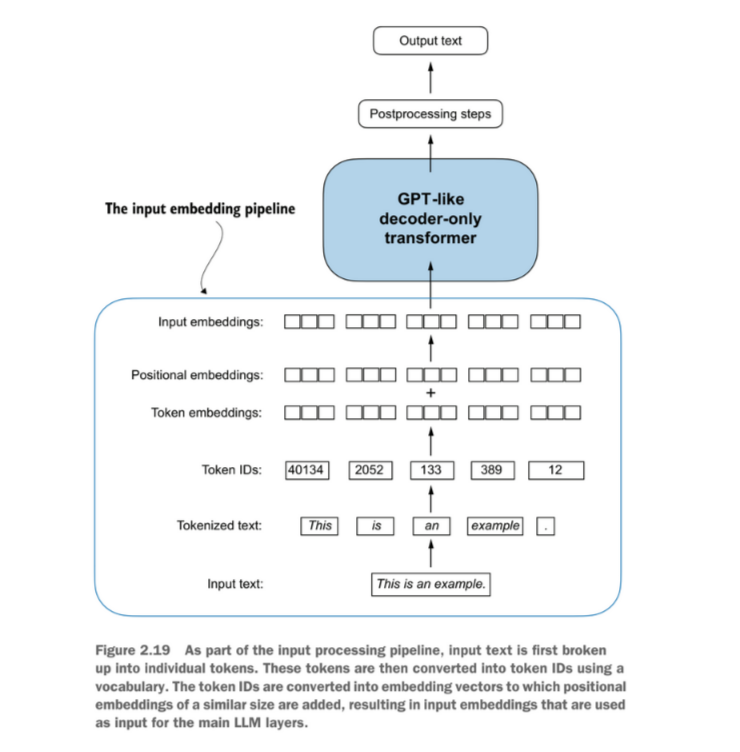